# CardioScope, Part 1: from raw ECG to beat-by-beat diagnosis

**BIOVANCE 2026, École Polytechnique de Sousse**. Workshop *Deep Learning for Cardiovascular Risk Detection*.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nevermind78/cardioscope-workshop/blob/main/Part1_ECG_to_Diagnosis.ipynb)

Today we build **CardioScope**, an assistant that reads a Holter ECG the way a cardiologist does:
it finds every heartbeat, labels it, and turns the labels into a patient-level arrhythmic risk profile.

This morning we build the beat classifier and, above all, we learn to **evaluate it honestly**.
This afternoon (Part 2) we turn it into a tool a clinician could trust.

| Lab | Question |
|---|---|
| 1 | What does an annotated ECG look like? |
| 2 | Can a 1D CNN learn to recognise abnormal beats? |
| 3 | Does it work on patients it has never seen? |
| 4 | What does a cardiologist use that our CNN ignores? |

**Colab tip:** *Runtime > Change runtime type > T4 GPU*. Without a GPU everything still runs, just slower.

In [ ]:
# Setup: run this cell first (about 1 minute on Colab)
%matplotlib inline
import os, sys, subprocess
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # avoid an OpenMP crash (MKL + PyTorch both bundle libiomp5md)
REPO_URL = "https://github.com/nevermind78/cardioscope-workshop.git"   # set once by the instructor
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not os.path.isdir("/content/cardioscope-workshop"):
        if "YOUR-ACCOUNT" not in REPO_URL:
            subprocess.run(["git", "clone", "-q", REPO_URL, "/content/cardioscope-workshop"], check=True)
        else:                                   # no GitHub repository: upload the workshop ZIP
            from google.colab import files
            print("Upload cardioscope-workshop.zip (given by the instructor)")
            zip_name = next(iter(files.upload()))
            subprocess.run(["unzip", "-q", "-o", zip_name, "-d", "/content"], check=True)
    os.chdir("/content/cardioscope-workshop")
    if os.getcwd() not in sys.path:                 # os.chdir alone doesn't update sys.path on Colab
        sys.path.insert(0, os.getcwd())
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements-colab.txt"], check=True)

import numpy as np, pandas as pd, torch
from cardioscope import config as C, data as D, viz
from cardioscope.models import CardioNet, count_parameters
from cardioscope.training import get_device, train_model, predict_logits, save_checkpoint, load_checkpoint
from cardioscope.metrics import per_class, summary
pd.set_option("display.width", 200)
DEVICE = get_device()
EPOCHS = int(os.environ.get("CARDIOSCOPE_EPOCHS", 12))
gpu = f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else " (no GPU: training takes ~3 min per model)"
print(f"PyTorch {torch.__version__} | device: {DEVICE}{gpu}")

## Lab 1. Meet the data: the MIT-BIH Arrhythmia Database

* 48 half-hour ambulatory ECG recordings from 47 subjects ( Hospital, Boston, 1975-1979), 2 leads, 360 Hz.
* Every beat was annotated independently by two or more cardiologists (about 110,000 labels).
* Freely available on PhysioNet (Open Data Commons Attribution License).

The download takes 1 to 2 minutes (about 90 MB; Colab downloads it, not your laptop).

In [ ]:
#D.download_mitdb()
sig, fs, samples, symbols = D.load_record(208)
print(f"Record 208: {len(sig) / fs / 60:.1f} min at {fs} Hz, {len(samples)} annotations")
pd.Series(symbols).value_counts().head(8).to_frame("count").T

In [ ]:
viz.plot_record(sig, fs, samples, symbols, start_s=60, dur_s=10, show_rr=True,
                title="Record 208, lead MLII. Letters: cardiologists' labels. Numbers: RR intervals (s)")

The labels follow the **ANSI/AAMI EC57** standard, which groups the beat types into 5 classes:

| AAMI class | Meaning | MIT-BIH symbols |
|---|---|---|
| **N** | normal or bundle branch block beat | N, L, R, e, j |
| **S** | supraventricular ectopic beat (premature atrial / junctional) | A, a, J, S |
| **V** | ventricular ectopic beat (PVC) | V, E |
| **F** | fusion of a ventricular and a normal beat | F |
| Q | paced or unclassifiable (excluded, as in most studies) | /, f, Q |

**Your turn (1 minute):** in the strip above, which beats look different? Which ones arrive early?

## From recordings to a beat dataset

Pipeline (see `cardioscope/data.py`): resample to 180 Hz, band-pass filter 0.5 to 40 Hz, cut a window of
0.25 s before and 0.46 s after each R peak, and compute the rhythm context of each beat.

**The golden rule (de Chazal et al., IEEE TBME 2004):** 22 patients (DS1) for training, 22 *other* patients (DS2) for testing.
Beats of one patient never appear on both sides.

In [5]:
data = D.build_dataset()
ds1, ds2 = D.by_records(data, C.DS1), D.by_records(data, C.DS2)
counts = {"DS1 (train)": D.class_counts(ds1), "DS2 (test)": D.class_counts(ds2)}
pd.DataFrame(counts).T

Loaded 100,630 beats from cache data\mitdb_beats_v2.npz


,N,S,V,F
DS1 (train),45824,943,3788,414
DS2 (test),44218,1836,3219,388


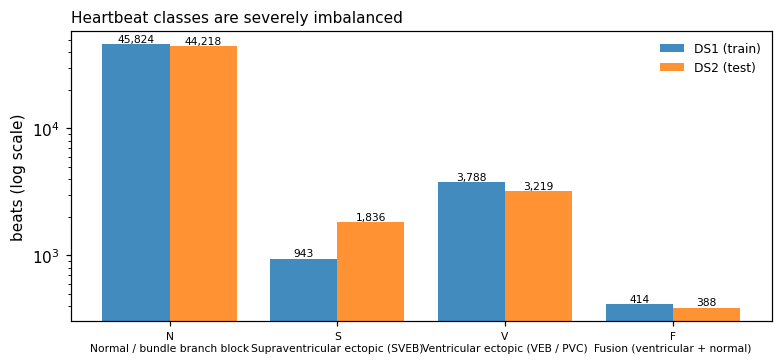

In [6]:
viz.plot_class_balance(counts)

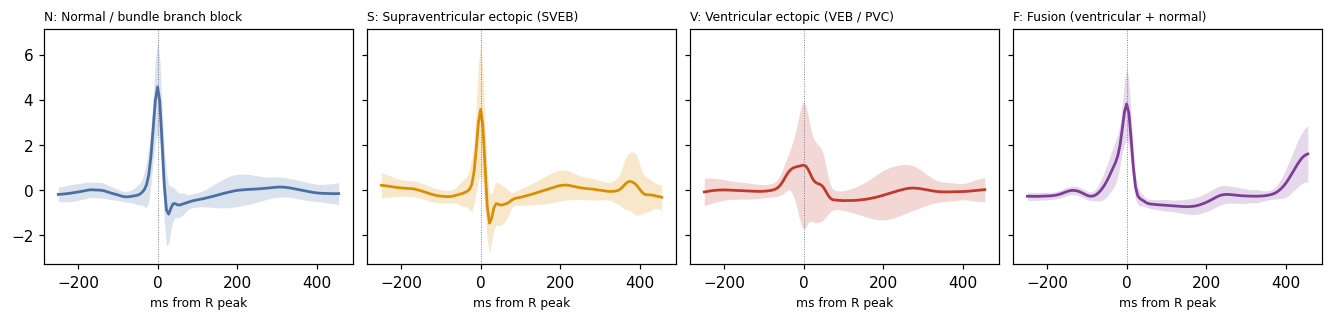

In [7]:
viz.plot_class_templates(ds1)

**Quick quiz.** A "model" that always answers *N*: what accuracy does it get on DS2?

In [8]:
always_n = np.zeros_like(ds2["y"])
print(f"Accuracy of 'always N': {100 * np.mean(always_n == ds2['y']):.1f} %")
per_class(ds2["y"], always_n)

Accuracy of 'always N': 89.0 %


,Beats,Se (%),PPV (%),F1 (%),Spec (%)
N,44218,100.0,89.0,94.2,0.0
S,1836,0.0,0.0,0.0,100.0
V,3219,0.0,0.0,0.0,100.0
F,388,0.0,0.0,0.0,100.0


Almost 90 % accuracy, and it misses every single abnormal beat. **Accuracy lies on imbalanced data.**
From now on we report, for each class, the **sensitivity** (Se: share of the real beats that are found) and the
**positive predictive value** (PPV: share of the alarms that are real), as required by AAMI EC57.

## Lab 2. A first 1D CNN: morphology only

`CardioNet` is a compact 1D ResNet (3 residual blocks, about 125,000 parameters) that looks at the shape of one beat.
To monitor training we keep 10 % of the DS1 beats aside, drawn at random. Keep in mind that these validation beats come
from **the same 22 patients** as the training beats.

In [9]:
train_set, val_set = D.holdout_split(ds1, frac=0.1, seed=0)
model_m = CardioNet()
print(model_m.stem, "...", f"\n{count_parameters(model_m):,} trainable parameters")

Sequential(
  (0): Conv1d(1, 16, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
  (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
) ... 
123,284 trainable parameters


In [10]:
hist_m = train_model(model_m, train_set, val_set, epochs=EPOCHS, device=DEVICE)

Training on cuda | 45,873 beats | 12 epochs | class weights N=0.18, S=1.27, V=0.63, F=1.92
epoch  1/12 | train loss 0.762 | val loss 0.429 | val macro-F1 0.626 | 3 s
epoch  2/12 | train loss 0.317 | val loss 0.258 | val macro-F1 0.742 | 1 s
epoch  3/12 | train loss 0.223 | val loss 0.244 | val macro-F1 0.789 | 1 s
epoch  4/12 | train loss 0.177 | val loss 0.123 | val macro-F1 0.869 | 1 s
epoch  5/12 | train loss 0.149 | val loss 0.128 | val macro-F1 0.858 | 1 s
epoch  6/12 | train loss 0.123 | val loss 0.167 | val macro-F1 0.772 | 1 s
epoch  7/12 | train loss 0.098 | val loss 0.106 | val macro-F1 0.871 | 1 s
epoch  8/12 | train loss 0.093 | val loss 0.078 | val macro-F1 0.913 | 1 s
epoch  9/12 | train loss 0.072 | val loss 0.081 | val macro-F1 0.897 | 1 s
epoch 10/12 | train loss 0.062 | val loss 0.074 | val macro-F1 0.902 | 1 s
epoch 11/12 | train loss 0.054 | val loss 0.069 | val macro-F1 0.912 | 1 s
epoch 12/12 | train loss 0.053 | val loss 0.067 | val macro-F1 0.908 | 1 s


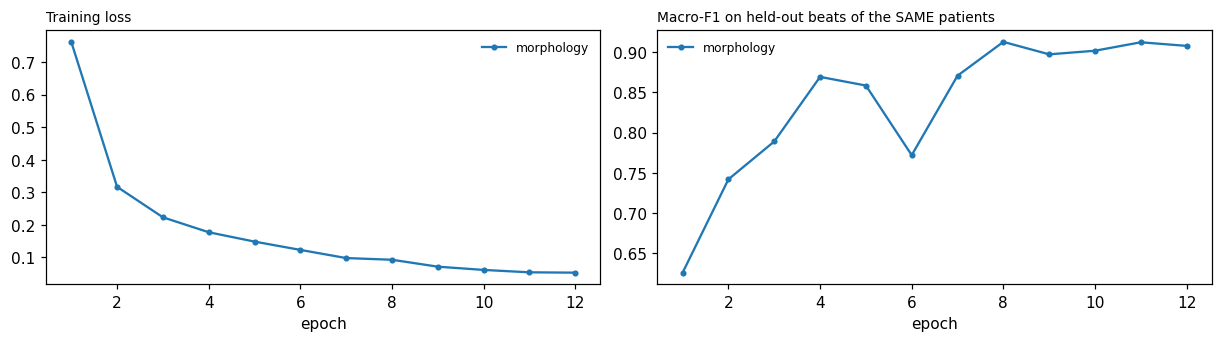

In [11]:
viz.plot_history({"morphology": hist_m})

## Lab 3. The leakage trap

Validation looks excellent. Now the real question: **what happens with 22 patients the network has never seen?**

In [12]:
pred_val = predict_logits(model_m, val_set).argmax(1)
pred_test = predict_logits(model_m, ds2).argmax(1)
pd.DataFrame({"same patients (validation)": summary(val_set["y"], pred_val),
              "NEW patients (DS2)": summary(ds2["y"], pred_test)}).T

,Accuracy (%),Macro-F1 (%),Se S (%),PPV S (%),Se V (%),PPV V (%),Se F (%),PPV F (%)
same patients (validation),98.8,90.8,91.5,78.2,97.9,96.6,90.2,75.5
NEW patients (DS2),75.4,40.0,21.8,8.4,94.4,45.5,1.8,0.2


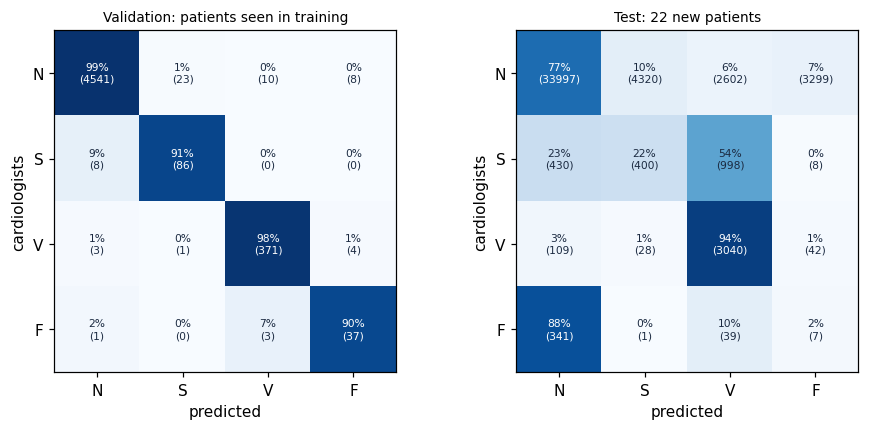

In [13]:
viz.plot_confusions({"Validation: patients seen in training": (val_set["y"], pred_val),
                     "Test: 22 new patients": (ds2["y"], pred_test)})

In [ ]:
per_class(ds2["y"], pred_test)

**What happened?** The network learned to recognise *patients* (electrode placement, individual QRS shape)
rather than *arrhythmias*. With a random split of the beats, the same patient sits in training and in test, and the
scores look spectacular. Many published "99 % accuracy" results come from exactly this mistake.

> **Rule:** in medical AI, split by patient, never by sample.

## Lab 4. Think like a cardiologist

A cardiologist reading a Holter uses two things our CNN ignores.

**1. Timing.** A premature atrial beat often has a perfectly normal shape: it is only *early*.
We give the network 5 rhythm features, each normalised by the patient's own rhythm:

  1. pre_RR / median_RR
  2. post_RR / median_RR
  3. local_RR / median_RR
  4. pre_RR / local_RR
  5. post_RR / pre_RR


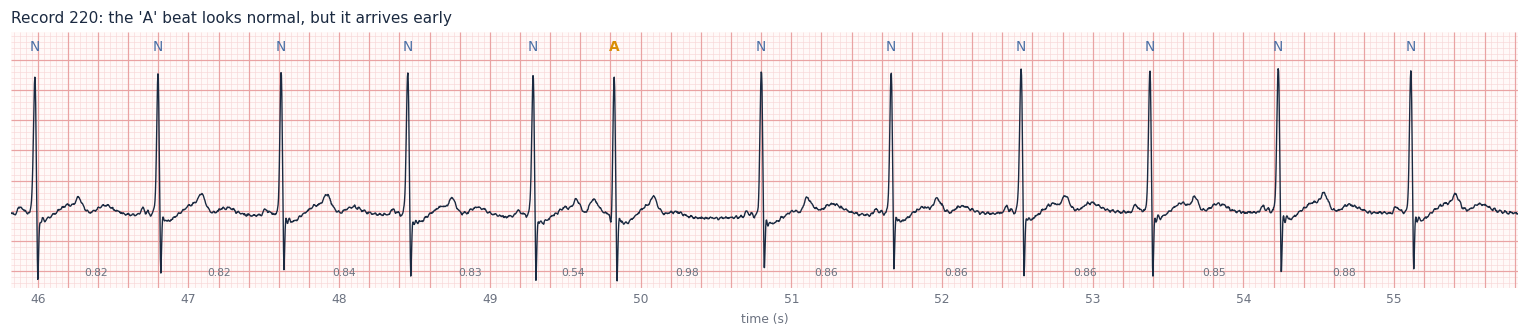

In [14]:
print("\n".join(f"  {i + 1}. {f}" for i, f in enumerate(C.RR_FEATURES)))
sig, fs, samples, symbols = D.load_record(220)
t_a = samples[symbols == "A"][0] / fs
viz.plot_record(sig, fs, samples, symbols, start_s=t_a - 4, dur_s=10, show_rr=True,
                title="Record 220: the 'A' beat looks normal, but it arrives early")

In [15]:
model_r = CardioNet(use_rr=True)
hist_r = train_model(model_r, train_set, val_set, epochs=EPOCHS, device=DEVICE)

Training on cuda | 45,873 beats | 12 epochs | class weights N=0.18, S=1.27, V=0.63, F=1.92
epoch  1/12 | train loss 0.782 | val loss 0.408 | val macro-F1 0.632 | 1 s
epoch  2/12 | train loss 0.246 | val loss 0.197 | val macro-F1 0.837 | 1 s
epoch  3/12 | train loss 0.157 | val loss 0.134 | val macro-F1 0.853 | 1 s
epoch  4/12 | train loss 0.123 | val loss 0.180 | val macro-F1 0.762 | 1 s
epoch  5/12 | train loss 0.100 | val loss 0.090 | val macro-F1 0.904 | 1 s
epoch  6/12 | train loss 0.085 | val loss 0.135 | val macro-F1 0.799 | 1 s
epoch  7/12 | train loss 0.070 | val loss 0.073 | val macro-F1 0.885 | 1 s
epoch  8/12 | train loss 0.061 | val loss 0.072 | val macro-F1 0.910 | 1 s
epoch  9/12 | train loss 0.050 | val loss 0.062 | val macro-F1 0.932 | 1 s
epoch 10/12 | train loss 0.042 | val loss 0.053 | val macro-F1 0.926 | 1 s
epoch 11/12 | train loss 0.039 | val loss 0.052 | val macro-F1 0.940 | 1 s
epoch 12/12 | train loss 0.035 | val loss 0.052 | val macro-F1 0.937 | 1 s


**2. The patient's usual beat.** A cardiologist judges a beat against *this patient's* normal beats: a wide QRS is
alarming in one patient and routine in a patient with bundle branch block. We compute each patient's **dominant beat**
(the median of all their beats) and give the network a second channel: *beat minus dominant beat*.

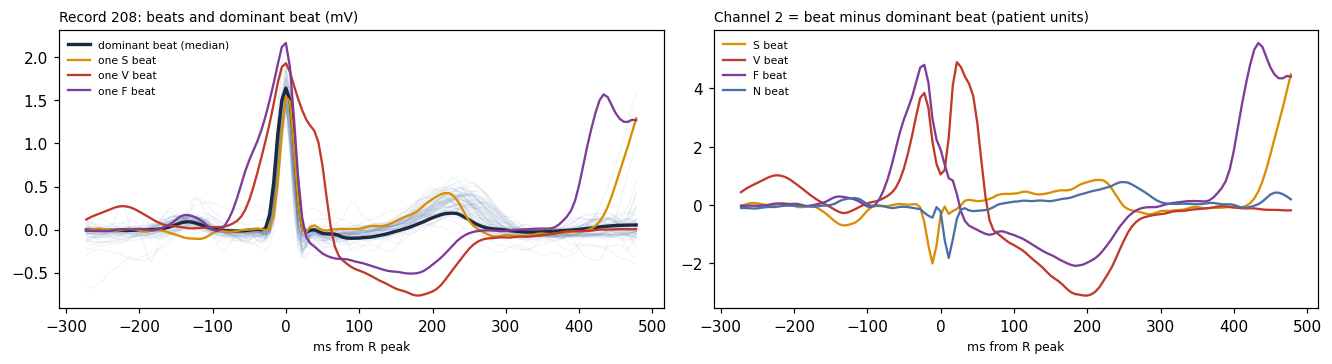

In [16]:
r = D.by_records(data, [208])
deviation, dominant = D.patient_context(r["X"])
viz.plot_dominant_beat(r["X"], deviation, dominant, r["y"], record=208)

In [17]:
model_c = CardioNet(use_rr=True, use_context=True)
hist_c = train_model(model_c, train_set, val_set, epochs=EPOCHS, device=DEVICE)

Training on cuda | 45,873 beats | 12 epochs | class weights N=0.18, S=1.27, V=0.63, F=1.92
epoch  1/12 | train loss 0.694 | val loss 0.230 | val macro-F1 0.764 | 1 s
epoch  2/12 | train loss 0.171 | val loss 0.213 | val macro-F1 0.788 | 1 s
epoch  3/12 | train loss 0.121 | val loss 0.089 | val macro-F1 0.898 | 1 s
epoch  4/12 | train loss 0.095 | val loss 0.090 | val macro-F1 0.897 | 1 s
epoch  5/12 | train loss 0.075 | val loss 0.083 | val macro-F1 0.899 | 1 s
epoch  6/12 | train loss 0.065 | val loss 0.105 | val macro-F1 0.880 | 1 s
epoch  7/12 | train loss 0.058 | val loss 0.058 | val macro-F1 0.939 | 1 s
epoch  8/12 | train loss 0.049 | val loss 0.058 | val macro-F1 0.924 | 1 s
epoch  9/12 | train loss 0.041 | val loss 0.045 | val macro-F1 0.935 | 1 s
epoch 10/12 | train loss 0.033 | val loss 0.050 | val macro-F1 0.940 | 1 s
epoch 11/12 | train loss 0.032 | val loss 0.043 | val macro-F1 0.938 | 1 s
epoch 12/12 | train loss 0.026 | val loss 0.042 | val macro-F1 0.939 | 1 s


### The verdict on the 22 unseen patients

In [18]:
models = {"1. morphology": model_m, "2. + rhythm": model_r, "3. + patient context": model_c}
preds = {name: predict_logits(m, ds2).argmax(1) for name, m in models.items()}
pd.DataFrame({name: summary(ds2["y"], p) for name, p in preds.items()}).T

,Accuracy (%),Macro-F1 (%),Se S (%),PPV S (%),Se V (%),PPV V (%),Se F (%),PPV F (%)
1. morphology,75.4,40.0,21.8,8.4,94.4,45.5,1.8,0.2
2. + rhythm,84.5,45.8,18.1,18.3,95.7,56.8,5.9,0.7
3. + patient context,93.9,60.9,35.6,37.4,95.7,92.1,13.1,21.5


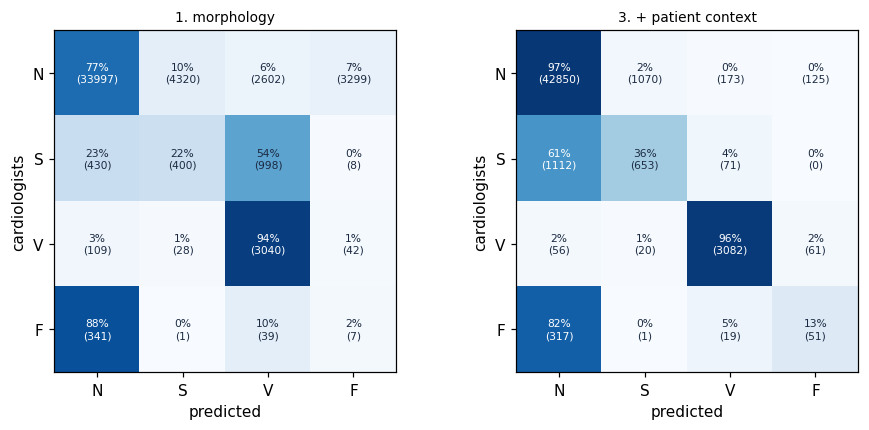

In [19]:
viz.plot_confusions({name: (ds2["y"], preds[name]) for name in ("1. morphology", "3. + patient context")})

### Honest limits: look at a few patients

In [20]:
def per_record(pred, records):
    rows = {}
    for rec in records:
        m = ds2["rec"] == rec
        rows[rec] = {**{f"true {c}": int((ds2["y"][m] == k).sum()) for k, c in enumerate(C.CLASSES)},
                     **{f"predicted {c}": int((pred[m] == k).sum()) for k, c in enumerate(C.CLASSES)}}
    return pd.DataFrame(rows).T

per_record(preds["3. + patient context"], [214, 219, 232, 233])

,true N,true S,true V,true F,predicted N,predicted S,predicted V,predicted F
214,2001,0,256,1,1995,6,257,0
219,2080,7,64,1,1558,527,63,4
232,397,1381,0,0,1409,357,12,0
233,2229,7,830,11,2228,7,829,13


* **233** (frequent PVCs) and **214** (left bundle branch block + PVCs): almost perfect.
* **232**: most beats are premature atrial beats conducted with a right bundle branch block. They are the majority,
  so they *define* the patient's median rhythm and dominant beat, and our two "cardiologist" features fail.
* **219**: atrial fibrillation. The rhythm is irregular by nature, so many normal beats look premature (false S).
  The model has no notion of AF: this is a *rhythm* problem, not a *beat* problem.

The detection of supraventricular beats in unseen patients remains an open research problem.

## Save your models for this afternoon

In [ ]:
os.makedirs("checkpoints", exist_ok=True)
for name, m in (("morph", model_m), ("rhythm", model_r), ("context", model_c)):
    print("saved", save_checkpoint(m, f"checkpoints/my_cardionet_{name}.pt", epochs=EPOCHS))
# Colab resets the machine after a long break. To keep your models, copy them to Google Drive:
# from google.colab import drive; drive.mount("/content/drive")
# !mkdir -p /content/drive/MyDrive/cardioscope && cp checkpoints/my_*.pt /content/drive/MyDrive/cardioscope/

## Challenge for the break

Change **one** thing, retrain, and compare on DS2 (never tune on DS2 in real research, use a patient-wise validation!).
Ideas: `weight_power=1.0` (stronger class weights), `width=32`, `epochs=20`, `lr=1e-3`.

In [ ]:
my_model = CardioNet(use_rr=True, use_context=True, width=16)
my_hist = train_model(my_model, train_set, val_set, epochs=EPOCHS, weight_power=0.5, device=DEVICE, verbose=False)
pd.DataFrame({"my model": summary(ds2["y"], predict_logits(my_model, ds2).argmax(1)),
              "3. + patient context": summary(ds2["y"], preds["3. + patient context"])}).T